In [1]:
# autoload
%load_ext autoreload
%autoreload 2
%matplotlib inline

# load pgl actions
from pgl import pglActions

import numpy as np
import mne

---

Load sesssion runs

---

In [2]:
newSession = pglActions.loadSession.execute()
if newSession: session = newSession

(pglParameterBatch->pglParameter:load) (pglParameter:load) Loaded parameter imageNum from:
/Users/justin/data/imagetask/s0000/session_2026-09-18/run_16-03-13/task01_imageTask/parameters/imageNum
(pglTaskData:display) Insufficient trial events found to display.
(pglParameterBatch->pglParameter:load) (pglParameter:load) Loaded parameter imageNum from:
/Users/justin/data/imagetask/s0000/session_2026-09-18/run_16-04-27/task01_imageTask/parameters/imageNum


---

Load Net Station mff file

---

In [3]:
session = pglActions.loadNetStation.execute(session=session)

(loadNetStation:_run) Loading NetStation MFF recording: /Users/justin/data/things/s0004/session_2026_09_21_eeg/S004_20260918_040438.mff


---

Align session timing with mne

---

In [4]:
newSession = pglActions.alignSessionToMNE.execute(session=session, channelName='D255')
if newSession: session = newSession

(pglParameterBatch->pglParameter:load) (pglParameter:load) Loaded parameter imageNum from:
/Users/justin/data/imagetask/s0000/session_2026-09-18/run_16-04-27/task01_imageTask/parameters/imageNum
(alignSessionToMNE:_run) Found session reference time: 1301062.1546738332
(alignSessionToMNE:_run) Found mne reference time: 8.614


(alignSegmentsToTriggers:_run) nSegments: 2760 nTriggers: 2770
(alignSegmentsToTriggers:_run) Matched 2760 segments to 2760 of 2770 triggers; 10 triggers were unmatched.
(alignSegmentsToTriggers:_run) Timing differences (trigger - segment, ms):
  Mean:           -14.245
  Median:         -18.390
  SD:            
28.313
  Minimum:        -64.404
  Maximum:        308.071
  Mean absolute:  23.766
  Max absolute:   308.071


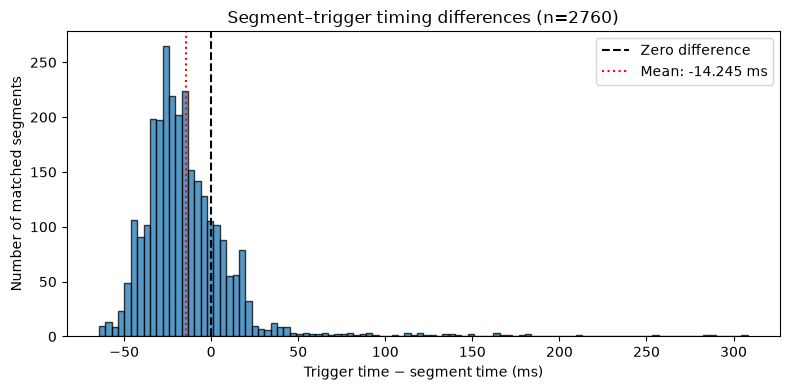

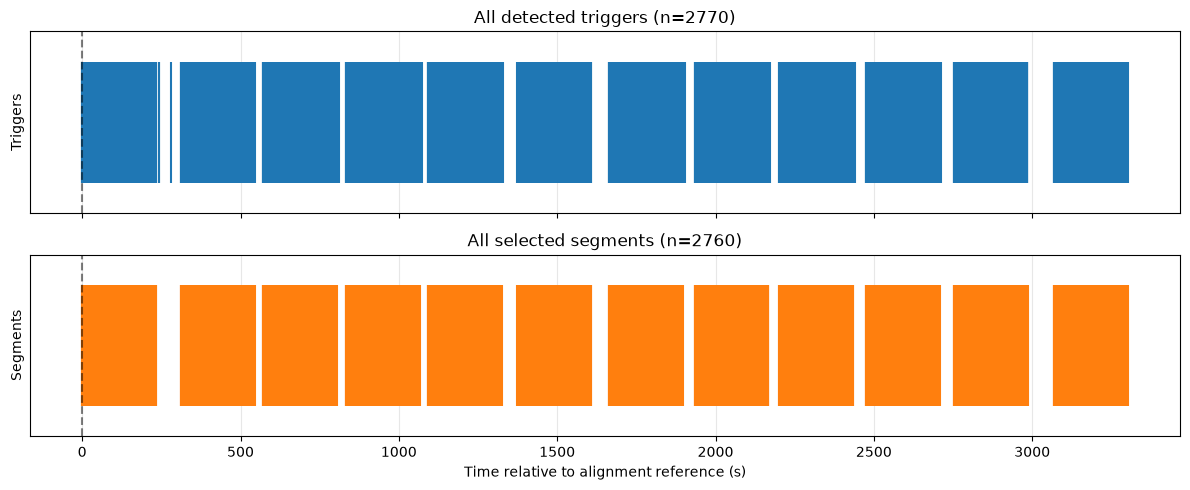

In [7]:
newSession = pglActions.alignSegmentsToTriggers.execute(session=session, channelName='D255', segments=[0,2,4,6,8,10,12,14,16,18])
if newSession: session = newSession

In [ ]:
from pgl import pglEventTrial, pglEventSegment
# get time of all event
run = session.runs[0]
task = run.tasks[0]

iTrial = -1
for e in task.data.events:
    if isinstance(e, pglEventTrial):
        iTrial+=1
    elif isinstance(e, pglEventSegment):
        # if we found the matching trial and segment
        print(f"{e.segmentNum}")
    
    

---

Concatenate

---

In [ ]:
session = pglActions.mneConcatenate.execute(session=session, all=True)


---

Filter

---

In [ ]:
session = pglActions.mneFilter.execute(session=session, lowCutoff=0.5, highCutoff=120.0, notch=True, notchFrequency=60.0)

---

Scratch code

---

In [ ]:
session.mne.raw

In [ ]:
stimPicks = mne.pick_types(session.mne.raw.info, meg=False, eeg=False, stim=True)
stimNames = [session.mne.raw.ch_names[i] for i in stimPicks]

for stimName in stimNames:
    stimData = session.mne.raw.get_data(picks=[stimName])[0]
    activeSamples = np.flatnonzero(stimData)
    if activeSamples.size:
        print(f"{stimName}: {activeSamples.size} nonzero samples, first at {activeSamples[0] / session.mne.raw.info['sfreq']:.3f} s, values={np.unique(stimData)}")

In [ ]:
stimPicks = mne.pick_types(session.mne.raw.info, meg=False, eeg=False, stim=True)
session.mne.raw.plot(picks=stimPicks, n_channels=len(stimPicks), duration=20, scalings="auto", remove_dc=False, clipping=None, title="Stimulus channels", block=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plotTriggers(raw, channelNames, startTime=0, duration=10):
    startSample = max(0, int(startTime * raw.info["sfreq"]))
    stopSample = min(raw.n_times, int((startTime + duration) * raw.info["sfreq"]))

    if not channelNames or stopSample <= startSample:
        raise ValueError("Choose at least one channel and a valid time window")

    triggerData = raw.get_data(picks=channelNames, start=startSample, stop=stopSample)
    plotTimes = np.arange(startSample, stopSample) / raw.info["sfreq"]
    fig, axes = plt.subplots(len(channelNames), 1, sharex=True, figsize=(14, max(3, 1.5 * len(channelNames))), squeeze=False)

    for ax, channelName, channelData in zip(axes[:, 0], channelNames, triggerData):
        ax.step(plotTimes, channelData, where="post")
        ax.set_ylabel(channelName, rotation=0, ha="right")
        ax.grid(True, alpha=0.3)

    axes[-1, 0].set_xlabel("Time from recording start (s)")
    fig.tight_layout()
    plt.show()

In [ ]:
plotTriggers(session.mne.raw, ["D255"], startTime=5, duration=245)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Detect rising edges of D255 pulses.
triggerData = session.mne.raw.get_data(picks=["D255"])[0]
pulseSamples = np.flatnonzero(np.diff((triggerData != 0).astype(int), prepend=0) == 1)

# Calculate intervals in milliseconds and select 800–1000 ms.
pulseIntervalsMs = np.diff(pulseSamples) / session.mne.raw.info["sfreq"] * 1000
zoomIntervals = pulseIntervalsMs[(pulseIntervalsMs >= 800) & (pulseIntervalsMs <= 1200)]

if zoomIntervals.size:
    print(f"{len(zoomIntervals)} intervals; mean: {zoomIntervals.mean():.2f} ms; median: {np.median(zoomIntervals):.2f} ms")

    # Center bins on the 2 ms sampling grid at 500 Hz.
    sampleMs = 1000 / session.mne.raw.info["sfreq"]
    binEdges = np.arange(800 - sampleMs / 2, 1200 + sampleMs, sampleMs)

    plt.figure(figsize=(12, 4))
    plt.hist(zoomIntervals, bins=binEdges, edgecolor="black")
    plt.xlim(900, 1200)
    plt.xticks(np.arange(800, 1201, 20))
    plt.xlabel("Time between consecutive D255 pulse onsets (ms)")
    plt.ylabel("Count")
    plt.title("D255 pulse interval distribution: 800–1000 ms")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No pulse intervals between 800 and 1000 ms")

In [ ]:
stimNames = [name for name, channelType in zip(session.mne.raw.ch_names, session.mne.raw.get_channel_types()) if channelType == "stim"]
print(stimNames)
print(getattr(session.mne.raw, "event_id", None))

In [ ]:
import mne

# Detect D255 onsets, including single-sample events.
events = mne.find_events(session.mne.raw, stim_channel="D255", output="onset", consecutive=True, shortest_event=1, initial_event=True)

if len(events):
    # Epoch EEG channels and baseline-correct using the 200 ms before D255.
    epochs = mne.Epochs(session.mne.raw, events, event_id=None, tmin=0.0, tmax=2.0, baseline=None, picks="eeg", preload=True, reject_by_annotation=True)

    print(f"Detected {len(events)} D255 onsets; retained {len(epochs)} epochs")

    if len(epochs):
        evoked = epochs.average()

        # Butterfly plot: all retained EEG channels overlaid.
        evoked.plot(spatial_colors=True, gfp=True, time_unit="s", ylim={"eeg": (-15, 15)}, titles="EEG average around D255")

        # Scalp voltage maps at selected post-trigger times, in seconds.
        evoked.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], ch_type="eeg", time_unit="s", colorbar=True)
    else:
        print("No usable epochs remain; check annotations and recording boundaries")
else:
    print("No D255 onsets found")

In [ ]:
import matplotlib.pyplot as plt
#evoked = session.mne.evoked.copy().pick(self.legPicks)
timeSeries = evoked.data  # shape: (n_channels, n_times)

sampleRate = evoked.info["sfreq"]

fftValues = np.fft.rfft(timeSeries, axis=1)
freqs = np.fft.rfftfreq(timeSeries.shape[1], d=1 / sampleRate)
magnitude = np.abs(fftValues)
magnitudeMean = magnitude.mean(axis=0)

figFft, ax = plt.subplots(figsize=(12, 6))
minFreq = 0
maxFreq= 20
ax.stem(freqs, magnitudeMean, linefmt="C0-", markerfmt="C0.", basefmt=" ")
ax.set(xlabel="Frequency (Hz)", ylabel="FFT magnitude", title=f"Evoked FFT magnitude (averaged across leg electrodes)", xlim=(minFreq, maxFreq))
figFft.tight_layout()

In [ ]:
import numpy as np

eegPicks = mne.pick_types(evoked.info, meg=False, eeg=True, exclude="bads")
postTriggerData = evoked.data[eegPicks][:, evoked.times >= 0]
peakAmplitudes = np.max(np.abs(postTriggerData), axis=1)
maxIndex = np.argmax(peakAmplitudes)
badChannel = evoked.ch_names[eegPicks[maxIndex]]

print(f"Largest response: {badChannel}, peak absolute amplitude = {peakAmplitudes[maxIndex] * 1e6:.2f} µV")

In [ ]:
if badChannel not in session.mne.raw.info["bads"]:
    session.mne.raw.info["bads"].append(badChannel)

In [ ]:
session.print()